# Process the AGAP airborne gravity data

We try to recreate the BAS processing steps, as outlined here: https://data.bas.ac.uk/full-record.php?id=GB/NERC/BAS/PDC/01310

In [ ]:
%load_ext autoreload
%autoreload 2


import boule as bl
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import airbornegeo

/home/sungw937/airbornegeo/src/airbornegeo/levelling.py:21: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Load data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_survey`.

In [2]:
data_df_full = pd.read_csv("../data/AGAP_gravity_survey.csv")
print(data_df_full.columns)
data_df_full["index"] = data_df_full.index
data_df_full.head()

Index(['Lon', 'Lat', 'Height_WGS1984', 'Date', 'Time', 'ST', 'CC', 'RB',
       'XACC', 'LACC', 'Still', 'Base', 'ST_real', 'Beam_vel', 'rec_grav',
       'Abs_grav', 'VaccCor', 'EotvosCor', 'LatCor', 'FaCor', 'HaccCor',
       'Free_air', 'FAA_filt', 'FAA_clip', 'Level_cor', 'FAA_level',
       'Fa_4600m', 'easting', 'northing', 'line_name', 'line', 'unixtime'],
      dtype='str')


,Lon,Lat,Height_WGS1984,Date,Time,ST,CC,RB,XACC,LACC,...,FAA_clip,Level_cor,FAA_level,Fa_4600m,easting,northing,line_name,line,unixtime,index
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,49.38,7.03,42.4,40.8,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09,0
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,49.45,7.04,42.4,40.8,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09,1
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,49.52,7.04,42.5,40.9,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09,2
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,49.58,7.03,42.5,40.9,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09,3
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,49.65,7.04,42.6,41.0,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09,4


In [3]:
# turn to geopandas geodataframe
data_df_full = gpd.GeoDataFrame(
    data_df_full,
    geometry=gpd.points_from_xy(x=data_df_full.easting, y=data_df_full.northing),
    crs="EPSG:3031",
)

In [4]:
# get only the raw columns
# we will perform the corrections ourselves and compare to their values
data_df = data_df_full.drop(
    columns=[
        "rec_grav",
        "Abs_grav",
        "VaccCor",
        "EotvosCor",
        "LatCor",
        "FaCor",
        "HaccCor",
        "Free_air",
        "FAA_filt",
        "FAA_clip",
        "Level_cor",
        "FAA_level",
        "Fa_4600m",
    ]
)

# reset names to match the expected names in airbornegeo
data_df = data_df.rename(
    columns={
        "Height_WGS1984": "height",
    }
)

data_df.head()

,Lon,Lat,height,Date,Time,ST,CC,RB,XACC,LACC,...,Base,ST_real,Beam_vel,easting,northing,line_name,line,unixtime,index,geometry
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,981970.73,11934.47,235.65,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09,0,POINT (1000023.79 226237.331)
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,981970.73,11934.47,681.05,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09,1,POINT (1000082.905 226246.631)
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,981970.73,11934.47,496.85,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09,2,POINT (1000142.048 226255.809)
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,981970.73,11896.47,-64.00,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09,3,POINT (1000201.195 226264.969)
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,981970.73,11888.95,257.30,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09,4,POINT (1000260.224 226274.157)


## Relative gravity
$$
g_{rel} = s (t +(b k)+c)
$$

where $g_{rel}$ is the relative gravity, $t$ is the true spring tension, $b$ is the beam velocity, $k$ is 30, $c$ is the cross-coupling, and $s$ is the meter scale value, which is 0.9966.

In [5]:
data_df["grav_relative"] = 0.9966 * (
    data_df["ST_real"] + (data_df["Beam_vel"] * 30) + data_df["CC"]
)
data_df.head()

,Lon,Lat,height,Date,Time,ST,CC,RB,XACC,LACC,...,ST_real,Beam_vel,easting,northing,line_name,line,unixtime,index,geometry,grav_relative
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,11934.47,235.65,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09,0,POINT (1000023.79 226237.331),18941.957628
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,11934.47,681.05,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09,1,POINT (1000082.905 226246.631),32258.636454
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,11934.47,496.85,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09,2,POINT (1000142.048 226255.809),26746.641174
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,11896.47,-64.00,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09,3,POINT (1000201.195 226264.969),9943.048302
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,11888.95,257.30,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09,4,POINT (1000260.224 226274.157),19539.558852


In [6]:
airbornegeo.plotly_points(
    data_df[::50],
    color_col="grav_relative",
    edge_width=0,
)

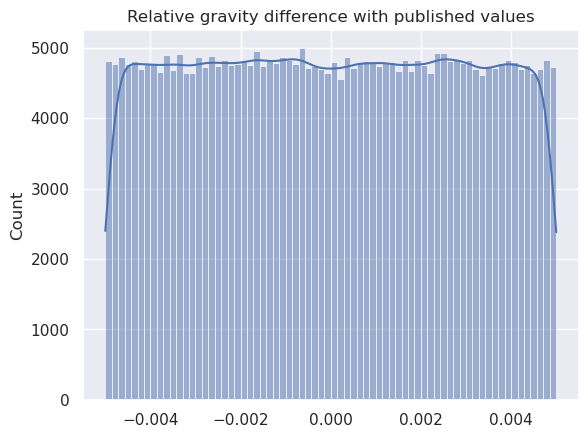

In [7]:
data_df_full = data_df_full.drop(columns=["grav_relative"], errors="ignore")
data_df_full = data_df_full.merge(
    data_df[["index", "grav_relative"]], on="index", how="left"
)
sns.histplot((data_df_full["rec_grav"] - data_df_full["grav_relative"]), kde=True)
plt.title("Relative gravity difference with published values")
plt.show()

In [8]:
# # for now just use there values
# data_df = data_df.drop(columns=['grav_relative'], errors='ignore')
# data_df = data_df.merge(data_df_full[['index', 'rec_grav']], on='index', how='left')
# data_df = data_df.rename(columns={'rec_grav': 'grav_relative'})

## Absolute gravity

Still readings are in mGal and were calculating assuming a 2nd order best fit to the approximately linear drift of the meter observed at the tie down points. For each line, there are 2-5 unique still values. For the whole survey, the base station readings are all equal to 981970.73 mGal.

Absolute gravity is then calculated as:
$$
g_{abs} = g_{rel} - g_{still} + g_{base}
$$

In [9]:
data_df["grav_absolute"] = data_df["grav_relative"] - data_df["Still"] + data_df["Base"]
data_df.head()

,Lon,Lat,height,Date,Time,ST,CC,RB,XACC,LACC,...,Beam_vel,easting,northing,line_name,line,unixtime,index,geometry,grav_relative,grav_absolute
0,77.252450,-80.583923,4156.1,2008-12-17,0 days 09:42:48,11934.47,2.61,-659.0,-49.0,273.0,...,235.65,1.000024e+06,226237.330771,11_DA500,1,1.229507e+09,0,POINT (1000023.79 226237.331),18941.957628,9.887747e+05
1,77.252672,-80.583377,4156.0,2008-12-17,0 days 09:42:49,11934.47,2.72,-368.6,-321.0,230.0,...,681.05,1.000083e+06,226246.631269,11_DA500,1,1.229507e+09,1,POINT (1000082.905 226246.631),32258.636454,1.002091e+06
2,77.252901,-80.582831,4156.1,2008-12-17,0 days 09:42:50,11888.95,-2.08,703.1,433.0,146.0,...,496.85,1.000142e+06,226255.809132,11_DA500,1,1.229507e+09,2,POINT (1000142.048 226255.809),26746.641174,9.965794e+05
3,77.253131,-80.582285,4156.4,2008-12-17,0 days 09:42:51,11888.95,0.50,625.1,566.0,223.0,...,-64.00,1.000201e+06,226264.969079,11_DA500,1,1.229507e+09,3,POINT (1000201.195 226264.969),9943.048302,9.797758e+05
4,77.253358,-80.581740,4156.6,2008-12-17,0 days 09:42:52,11888.95,-1.73,575.1,108.0,205.0,...,257.30,1.000260e+06,226274.156809,11_DA500,1,1.229507e+09,4,POINT (1000260.224 226274.157),19539.558852,9.893723e+05


In [10]:
airbornegeo.plotly_points(
    data_df[::50],
    color_col="grav_absolute",
    edge_width=0,
)

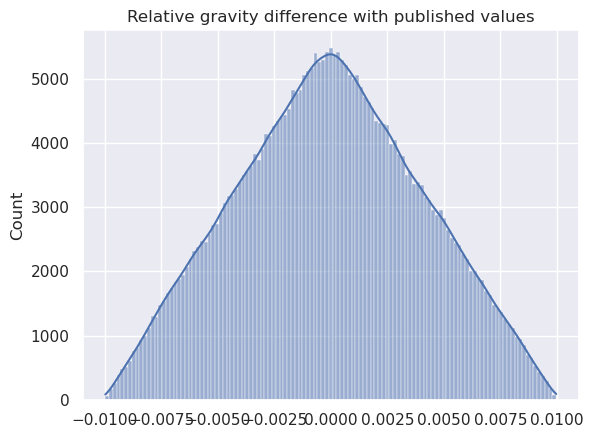

In [11]:
data_df_full = data_df_full.drop(columns=["grav_absolute"], errors="ignore")
data_df_full = data_df_full.merge(
    data_df[["index", "grav_absolute"]], on="index", how="left"
)
sns.histplot((data_df_full["Abs_grav"] - data_df_full["grav_absolute"]), kde=True)
plt.title("Relative gravity difference with published values")
plt.show()

In [12]:
# # for now just use their values
# data_df = data_df.drop(columns=['grav_absolute'], errors='ignore')
# data_df = data_df.merge(data_df_full[['index', 'Abs_grav']], on='index', how='left')
# data_df = data_df.rename(columns={'Abs_grav': 'grav_absolute'})

## Calculate and check sampling frequency

Average jump between points: 1.09 seconds


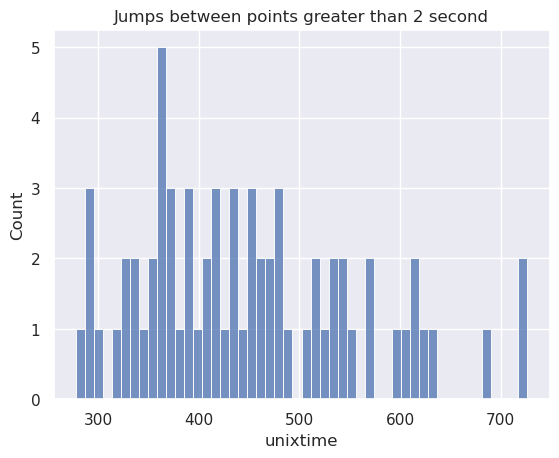

count     67.000000
mean     449.820896
std      108.607428
min      278.000000
25%      366.000000
50%      434.000000
75%      522.000000
max      726.000000
Name: unixtime, dtype: float64

In [24]:
jumps_df = data_df.groupby("line").unixtime.diff()
print(f"Average jump between points: {np.mean(jumps_df):.2f} seconds")

sns.histplot(
    jumps_df[jumps_df > 2],
    bins=50,
)
plt.title("Jumps between points greater than 2 second")
plt.show()

jumps_df[jumps_df > 2].describe()

In [27]:
durations = []
for name, df in data_df.groupby("line"):
    duration = df.unixtime.max() - df.unixtime.min()
    durations.append(duration)
    print(f"Line {name} duration: {duration / 3600:.2f} hours")

Line 1 duration: 1.19 hours
Line 2 duration: 0.42 hours
Line 3 duration: 1.05 hours
Line 4 duration: 1.16 hours
Line 5 duration: 1.11 hours
Line 6 duration: 0.94 hours
Line 7 duration: 0.99 hours
Line 8 duration: 1.07 hours
Line 9 duration: 1.12 hours
Line 10 duration: 1.24 hours
Line 11 duration: 1.12 hours
Line 12 duration: 1.05 hours
Line 13 duration: 1.09 hours
Line 14 duration: 0.94 hours
Line 15 duration: 1.16 hours
Line 16 duration: 1.01 hours
Line 17 duration: 1.03 hours
Line 18 duration: 1.19 hours
Line 19 duration: 0.91 hours
Line 20 duration: 0.94 hours
Line 21 duration: 1.01 hours
Line 22 duration: 1.09 hours
Line 23 duration: 1.25 hours
Line 24 duration: 1.18 hours
Line 25 duration: 1.09 hours
Line 26 duration: 1.17 hours
Line 27 duration: 0.86 hours
Line 28 duration: 1.09 hours
Line 29 duration: 1.05 hours
Line 30 duration: 0.29 hours
Line 31 duration: 0.85 hours
Line 32 duration: 1.15 hours
Line 33 duration: 0.97 hours
Line 34 duration: 1.01 hours
Line 35 duration: 1.07 

In [28]:
print(f"Average line duration: {np.mean(durations) / 3600:.2f} hours")
print(f"Min duration: {np.min(durations) / 3600:.2f} hours")
print(f"Max duration: {np.max(durations) / 3600:.2f} hours")

Average line duration: 1.01 hours
Min duration: 0.29 hours
Max duration: 1.58 hours


## Vertical acceleration corrections

The vertical acceleration is calculated as the 2nd derivative of flight altitude w.r.t. time with a 3 point mean filter applied after differencing to reduce short wavelength noise.

In [29]:
# data_df['vertical_acceleration'] = airbornegeo.vertical_acceleration(
#     data_df,
#     time_threshold=10,
#     flight_col_name="flight",
#     height_col_name="height",
#     smoothing_window=3,
# )

# data_df['vertical_acceleration'] *= 100e3
# data_df

In [30]:
# airbornegeo.plotly_points(
#     data_df[::50],
#     color_col="vertical_acceleration",
#     edge_width=0,
# )

In [31]:
# data_df_full = data_df_full.drop(columns=['vertical_acceleration'], errors='ignore')
# data_df_full = data_df_full.merge(data_df[['index', 'vertical_acceleration']], on='index', how='left')
# sns.histplot((data_df_full.VaccCor - data_df_full.vertical_acceleration), kde=True)
# plt.title("Vertical acceleration difference with published values")
# plt.show()

In [32]:
# for now just use the BAS values
data_df = data_df.drop(columns=["vertical_acceleration"], errors="ignore")
data_df = data_df.merge(data_df_full[["index", "VaccCor"]], on="index", how="left")
data_df = data_df.rename(columns={"VaccCor": "vertical_acceleration"})

## Horizontal acceleration corrections

For this survey the approximation of Swain 1996 was used, assuming a damping of 0.707 and a platform period of 4 minutes.

In [33]:
# data_df['horizontal_acceleration'] = (
#     data_df.XACC**2 +
#     data_df.LACC**2 -
#     (np.diff(airbornegeo.eastward_velocity(
#         data_df.Lat.values, data_df.Lon.values, data_df.unixtime.values
#     ), prepend=np.nan) / data_df.unixtime.diff() )**2 -
#     (np.diff(airbornegeo.northward_velocity(
#         data_df.Lat.values, data_df.Lon.values, data_df.unixtime.values
#     ), prepend=np.nan) / data_df.unixtime.diff() )**2
# ) / 2*data_df.grav_relative

In [34]:
# airbornegeo.plotly_points(
#     data_df[::50],
#     color_col="horizontal_acceleration",
#     edge_width=0,
# )

In [35]:
# for now just use the BAS values
data_df = data_df.drop(columns=["horizontal_acceleration"], errors="ignore")
data_df = data_df.merge(data_df_full[["index", "HaccCor"]], on="index", how="left")
data_df = data_df.rename(columns={"HaccCor": "horizontal_acceleration"})

## Eotvos correction

Following Harlan 1968: https://github.com/PFPE/shipgrav/blob/e84b33cc6fcfddf0e18736cd1205620d82e16e91/shipgrav/grav.py#L194

In [36]:
# data_df['eotvos_correction'] = airbornegeo.eotvos_correction(
#     data_df.Lat.values,
#     data_df.Lon.values,
#     data_df.unixtime.values,
# )
# data_df

In [37]:
# airbornegeo.plotly_points(
#     data_df[::50],
#     color_col="eotvos_correction",
#     edge_width=0,
# )

In [38]:
# airbornegeo.plotly_points(
#     data_df_full[::50],
#     color_col="EotvosCor",
#     edge_width=0,
# )

In [39]:
# data_df_full = data_df_full.merge(data_df[['index', 'eotvos_correction']], on='index', how='left')
# sns.histplot((data_df_full.EotvosCor - data_df_full.eotvos_correction), kde=True)
# plt.title("Eötvös correction difference with published values")
# plt.show()

In [40]:
# for now just use the BAS values
data_df = data_df.drop(columns=["eotvos_correction"], errors="ignore")
data_df = data_df.merge(data_df_full[["index", "EotvosCor"]], on="index", how="left")
data_df = data_df.rename(columns={"EotvosCor": "eotvos_correction"})

## Observed gravity

In [41]:
data_df["grav_observed"] = (
    data_df["grav_absolute"]
    - data_df["vertical_acceleration"]
    + data_df["eotvos_correction"]
    - (0.5 * data_df["horizontal_acceleration"])
)

In [42]:
airbornegeo.plotly_points(
    data_df[::50],
    color_col="grav_observed",
    edge_width=0,
)

## Normal gravity corrections 

BAS used a separate latitude correction and free-air correction. We will instead combine them with a Normal gravity correction.

In [43]:
# Calculate normal gravity using the WGS84 ellipsoid
ellipsoid = bl.WGS84

data_df["grav_normal"] = ellipsoid.normal_gravity(data_df.Lat, data_df.height)

# The disturbance is the observed minus normal gravity (calculated at the
# observation point)
data_df["grav_disturbance"] = data_df.grav_observed - data_df.grav_normal

In [44]:
# # for now just use the BAS values
# data_df = data_df.drop(columns=['grav_disturbance'], errors='ignore')
# data_df = data_df.merge(data_df_full[['index', 'Free_air']], on='index', how='left')
# data_df = data_df.rename(columns={'Free_air': 'grav_disturbance'})

In [45]:
airbornegeo.plotly_points(
    data_df[::50],
    color_col="grav_disturbance",
    edge_width=0,
)

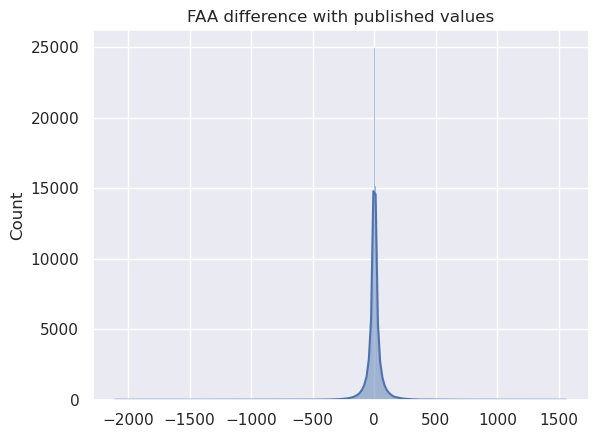

In [46]:
data_df_full = data_df_full.drop(columns=["grav_disturbance"], errors="ignore")
data_df_full = data_df_full.merge(
    data_df[["index", "grav_disturbance"]], on="index", how="left"
)
sns.histplot((data_df_full["Free_air"] - data_df_full["grav_disturbance"]), kde=True)
plt.title("FAA difference with published values")
plt.show()

## Filtering

Filtered free air anomaly (FAA_filt) used 9 km 1/2 wavelength space domain kernel filter (Holt et al., 2006).

In [47]:
# we need to filter based on horizontal distance along the flight line, so first we need to calculate the
# distance along each line
data_df["distance_along_line"] = airbornegeo.along_track_distance(
    data_df,
    groupby_column="line",
)
data_df[["easting", "northing", "line", "unixtime", "distance_along_line"]]

,easting,northing,line,unixtime,distance_along_line
0,1.000024e+06,226237.330771,1,1.229507e+09,0.000000
1,1.000083e+06,226246.631269,1,1.229507e+09,59.842447
2,1.000142e+06,226255.809132,1,1.229507e+09,119.693401
3,1.000201e+06,226264.969079,1,1.229507e+09,179.545645
4,1.000260e+06,226274.156809,1,1.229507e+09,239.285174
...,...,...,...,...,...
333988,1.587964e+06,496507.950674,100,1.230382e+09,78906.532032
333989,1.587973e+06,496454.987752,100,1.230382e+09,78960.299070
333990,1.587983e+06,496401.908627,100,1.230382e+09,79014.166666
333991,1.587992e+06,496348.713306,100,1.230382e+09,79068.134996


In [49]:
airbornegeo.plotly_points(
    data_df[::10],
    color_col="distance_along_line",
    hover_cols=["line"],
    size=3,
    edge_width=0,
)

In [50]:
data_df["grav_disturbance_filt"] = airbornegeo.filter_by_line(
    data_df,
    filt_type="g19000+l",
    data_column="grav_disturbance",
    filter_by_column="distance_along_line",
    line_column="line",
    pad_width_percentage=10,
)

In [51]:
airbornegeo.plotly_points(
    data_df[::50],
    color_col="grav_disturbance_filt",
    edge_width=0,
)

In [52]:
airbornegeo.plotly_points(
    data_df_full[::50],
    color_col="FAA_filt",
    edge_width=0,
)

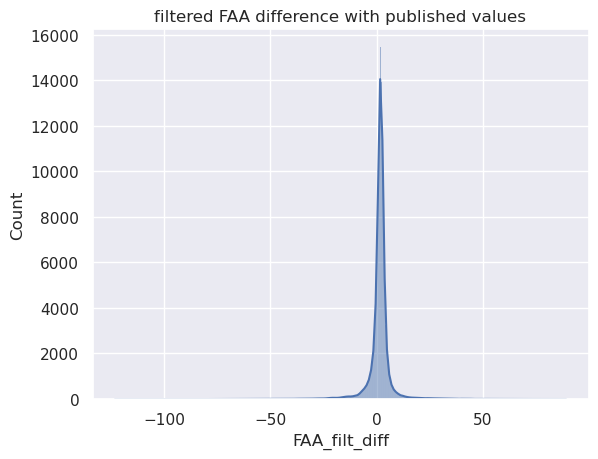

In [53]:
data_df_full = data_df_full.drop(columns=["grav_disturbance_filt"], errors="ignore")
data_df_full = data_df_full.merge(
    data_df[["index", "grav_disturbance_filt"]], on="index", how="left"
)
data_df_full["FAA_filt_diff"] = (
    data_df_full["FAA_filt"] - data_df_full["grav_disturbance_filt"]
)
sns.histplot((data_df_full["FAA_filt_diff"]), kde=True)
plt.title("filtered FAA difference with published values")
plt.show()

In [54]:
airbornegeo.plotly_points(
    data_df_full[::50],
    color_col="FAA_filt_diff",
    edge_width=0,
)

In [55]:
# save to csv for further levelling notebook
# eventually will use our version, but for checking the levelling is working correctly,
# we will just use their version
df = data_df
df = df[
    [
        "line",
        "easting",
        "northing",
        "height",
        "unixtime",
        "distance_along_line",
        "index",
    ]
]
df = df.merge(data_df_full[["index", "FAA_filt"]], on="index", how="left")
df = df.rename(columns={"FAA_filt": "grav_disturbance_filt"})
df = df.merge(data_df_full[["index", "Level_cor"]], on="index", how="left")
df = df.rename(columns={"Level_cor": "level_correction"})
df = df.merge(data_df_full[["index", "FAA_level"]], on="index", how="left")
df = df.rename(columns={"FAA_level": "grav_disturbance_filt_level"})

len_before = len(df)
df = df.dropna(how="any")
len_after = len(df)

df = df.drop(columns=["index"], errors="ignore")
df = df.reset_index(drop=True)

print(f"Dropped {len_before - len_after} rows with NaN values")

Dropped 1112 rows with NaN values


In [56]:
df.to_csv("../data/AGAP_gravity_survey_processed.csv", index=False)